In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii


plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

Mpc_cm = 3.086*10**24 #Mpc converted to cm
Jansky = 1e-23 #erg/s/cm^2/Hz

In [3]:
cendes_event_distances = ascii.read("cendes_distances.txt",delimiter='\t')

In [4]:
cendes2024=ascii.read("cendes_mrt.txt")

In [9]:
# cendes2024.add_column(col=-1,name='Distance (Mpc)')
for i,object_name in enumerate(cendes_event_distances['Object']):
    if object_name in np.unique(cendes2024['Object']):
        print(object_name)
        index = np.where(cendes2024['Object'] == object_name)[0][0]
        # print(cendes2024['Object'][index])
        # print(index)
        cendes2024['Distance (Mpc)'][index] = cendes_event_distances['Distance (Mpc)'][i]

iPTF16fnl
AT2019dsg
ASASSN-14ae
PS16dtm
AT2018zr
AT2018dyb
AT2018hco
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
iPTF15af
iPTF16axa
AT2017eqx
AT2018fyk
AT2018lna


In [10]:
cendes2024

Object,Tel,Code,Date,dt,Freq,l_S,S,e_S,Distance (Mpc)
,,,,d,GHz,,mJy,mJy,
str11,str7,str18,str12,int64,str5,str1,float64,float64,int64
iPTF16fnl,VLA,20A-492,2020 May 24,1365,6,--,0.045,0.001,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,3,<,0.514,--,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,5,--,0.028,0.008,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,7,--,0.031,0.007,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,9,--,0.024,0.006,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,11,--,0.023,0.008,71
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.25,<,0.514,--,230
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.75,--,0.114,0.033,230


In [29]:
dict_events = {}

for name in np.unique(np.array(cendes2024['Object'])):
    print(name)
    dt_array_temp = np.array([])
    freq_array_temp = np.array([])
    fluxdensity_array_temp = np.array([])
    err_fluxdensity_array_temp = np.array([])
    luminosity_array_temp = np.array([])
    err_luminosity_array_temp = np.array([])
    for i in range(len(cendes2024['Object'])):
        if cendes2024['Object'][i] == name:
            try:
                float(cendes2024['Freq'][i])
            except:
                continue
            # for i,object_name in enumerate(cendes_event_distances['Object']):
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            # print(cendes_event_distances['Object'][index])
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes2024['Object'][i], cendes2024['dt'][i],cendes2024['Freq'][i],cendes2024['S'][i],cendes2024['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes2024['dt'][i])
            freq_array_temp = np.append(freq_array_temp, float(cendes2024['Freq'][i]))
            fluxdensity_array_temp = np.append(fluxdensity_array_temp, cendes2024['S'][i])
            err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, cendes2024['e_S'][i])
            luminosity_array_temp = np.append(luminosity_array_temp, cendes2024['S'][i]*lum_fac)
            err_luminosity_array_temp = np.append(err_luminosity_array_temp, cendes2024['e_S'][i]*lum_fac)
    dict_events[name] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                         'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

ASASSN-14ae
AT2017eqx
AT2018dyb
AT2018fyk
AT2018hco
AT2018lna
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
PS16dtm
iPTF15af
iPTF16axa
iPTF16fnl


In [30]:
dict_events['AT2019eve']['freq (GHz)']

array([ 3.  ,  3.  ,  6.  ,  1.25,  1.75,  2.5 ,  3.5 ,  5.  ,  7.  ,
        9.  , 11.  , 13.5 , 16.5 , 20.  , 24.  ,  0.88,  1.36,  2.1 ,
        5.5 ,  9.  , 17.  , 19.  ,  1.25,  1.75,  2.5 ,  3.5 ,  5.  ,
        7.  ,  9.  , 11.  , 13.5 , 16.5 , 20.  , 24.  ,  0.88])

(10.0, 10000.0)

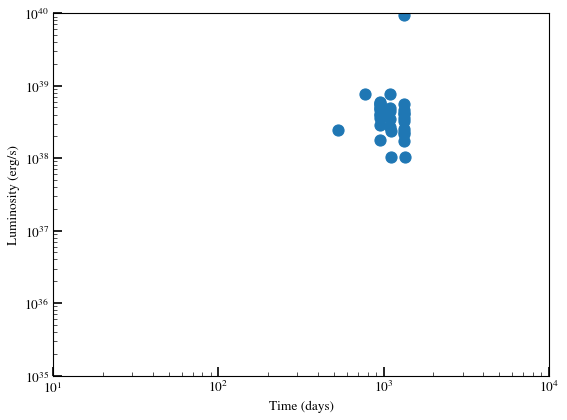

In [34]:
plt.scatter(dict_events['AT2019eve']['times (d)'],dict_events['AT2019eve']['freq (GHz)']*1e9*dict_events['AT2019eve']['Lnu (erg/s/Hz)'],label='AT2019eve')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time (days)')
plt.ylabel('Luminosity (erg/s)')
plt.ylim(1e35,1e40)
plt.xlim(1e1,1e4)

flux (mJy)

In [11]:
plt.close('all')

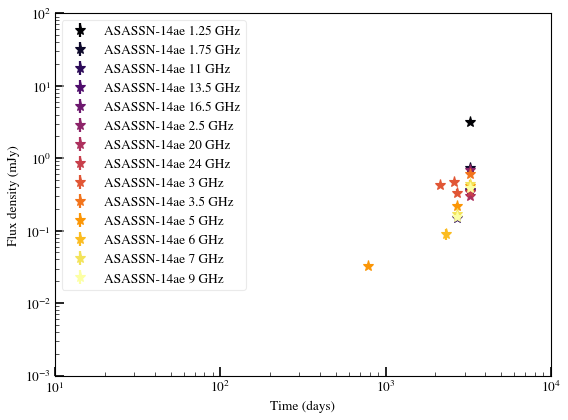

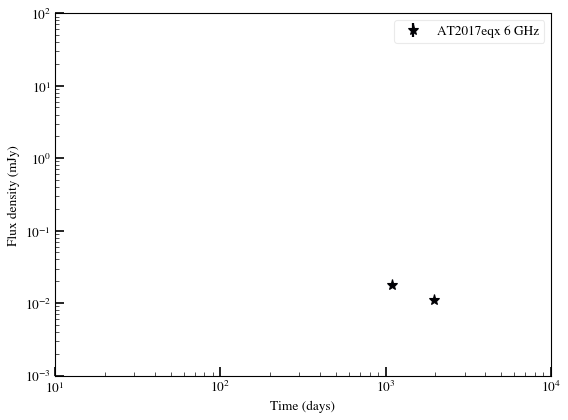

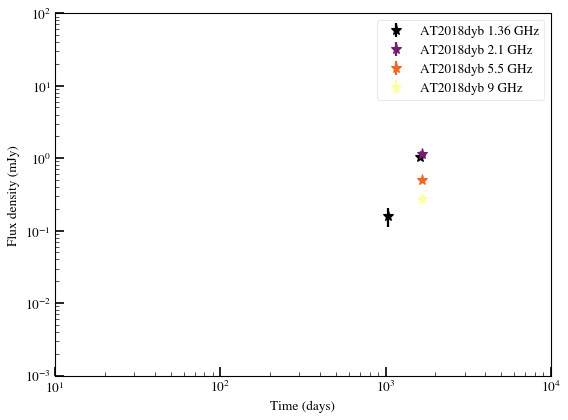

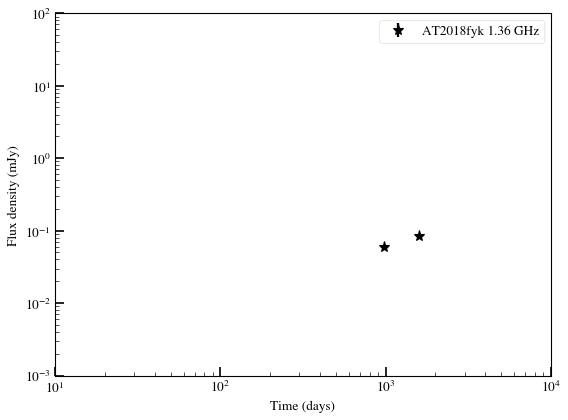

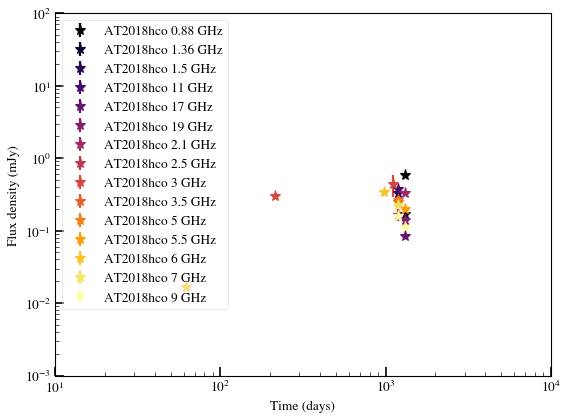

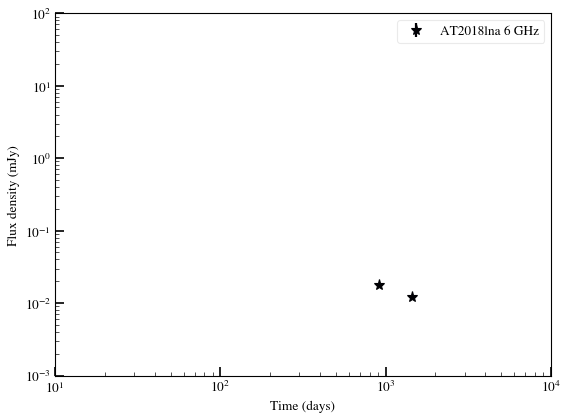

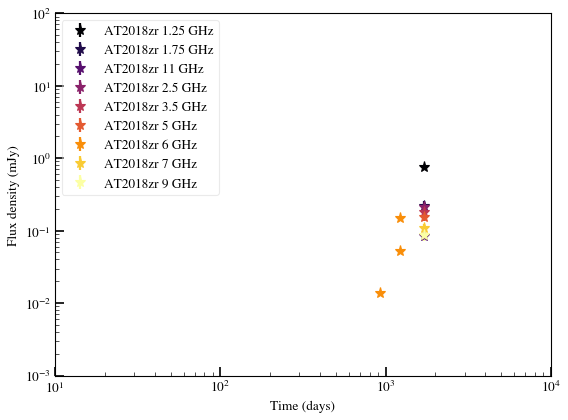

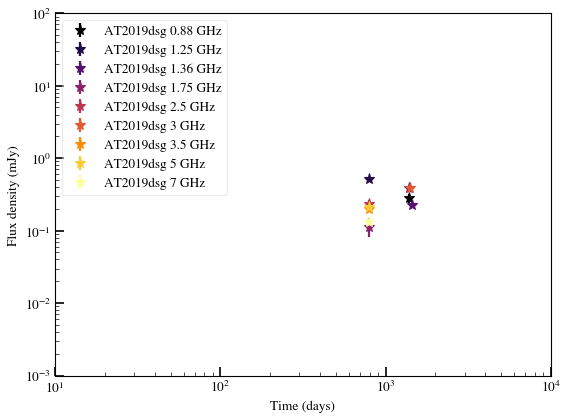

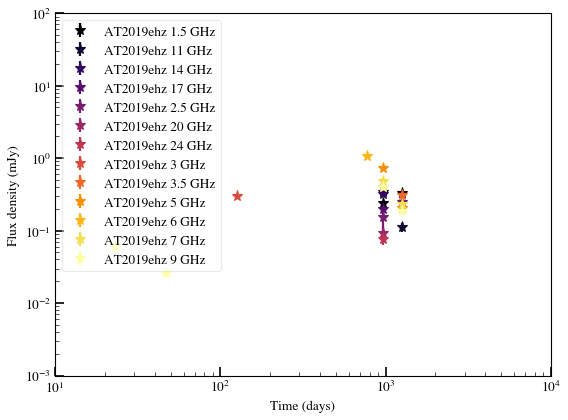

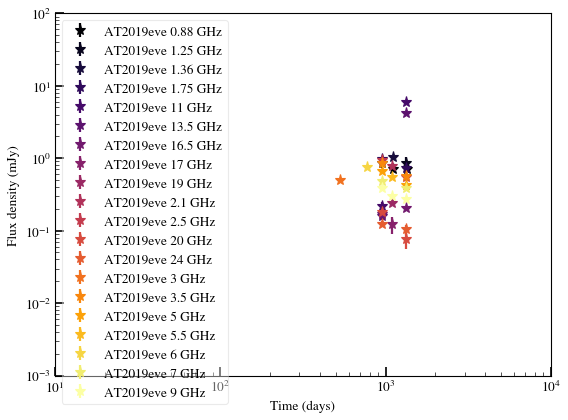

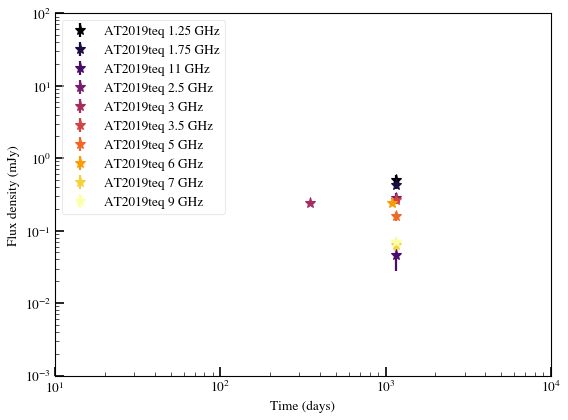

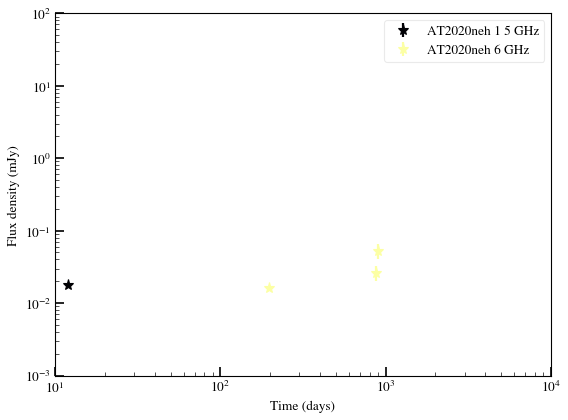

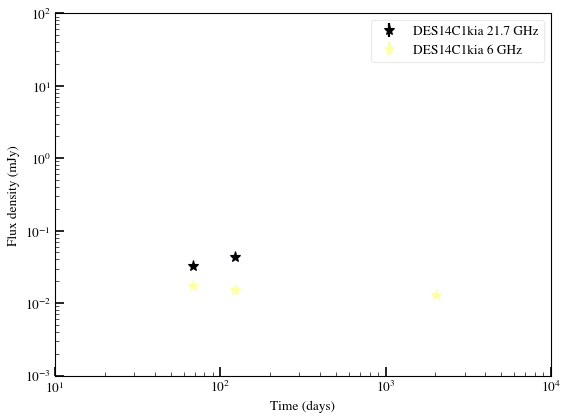

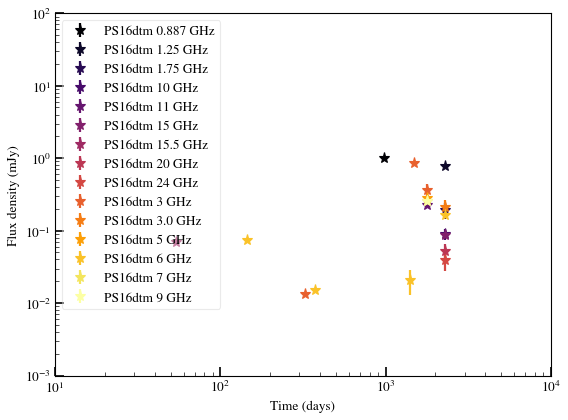

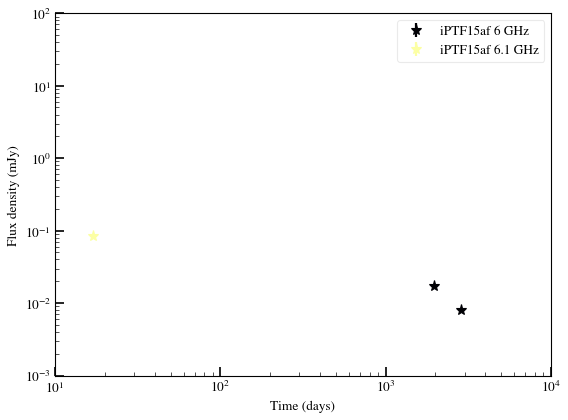

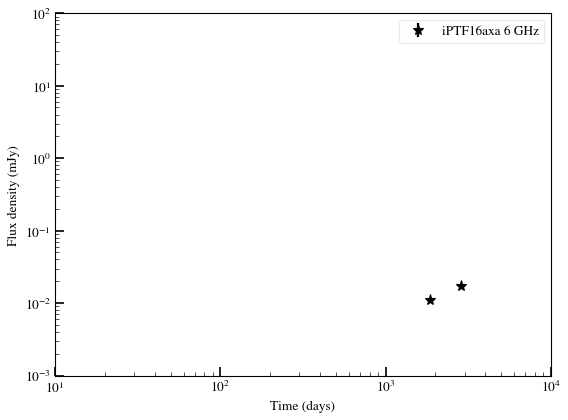

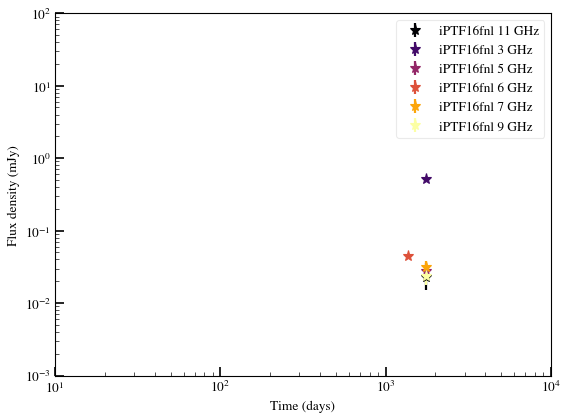

In [9]:
for event in dict_events.keys():
    # if event != 'ASASSN-14ae':
    #     continue
    colors_array = plt.cm.inferno(np.linspace(0, 1, len(np.unique(dict_events[event]['freq (GHz)']))))
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    fig,ax = plt.subplots(figsize=(8, 6))
    for freq, color in zip(np.unique(dict_events[event]['freq (GHz)']), colors_array):
        # print(color,freq)
        unique = True
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                if unique:
                    label = f'{event} {freq} GHz'
                else:
                    label = None
                ax.errorbar(dict_events[event]['times (d)'][i], dict_events[event]['flux density (mJy)'][i], yerr=dict_events[event]['error (mJy)'][i], fmt='*', color=color, label=label)
                unique=False
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(10,1e4)
    ax.set_ylim(1e-3,1e2)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Flux density (mJy)')
    plt.legend()

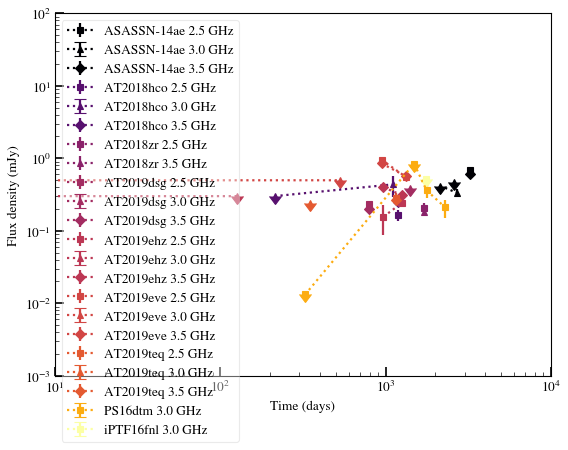

In [39]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)

        # try:
        if np.abs(float(freq)-3) > 0.5:
            continue
        # except:
        #     print(freq)
        #     continue
        # unique = True
        marker_num+=1
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                # if unique:
                #     label = f'{event} {freq} GHz'
                # else:
                #     label = None
        # print(freq_array)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

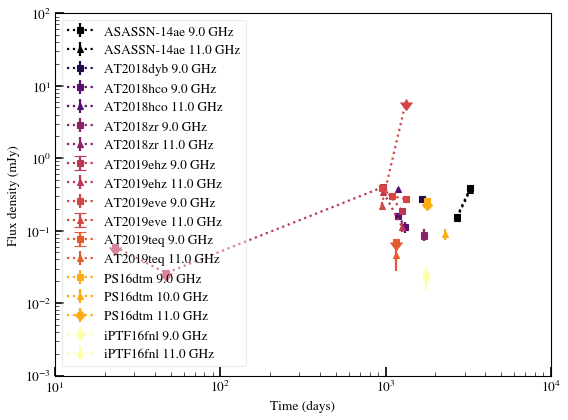

In [40]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)

        # try:
        if np.abs(float(freq)-10) > 1:
            continue
        # except:
        #     print(freq)
        #     continue
        # unique = True
        marker_num+=1
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                # if unique:
                #     label = f'{event} {freq} GHz'
                # else:
                #     label = None
        # print(freq_array)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

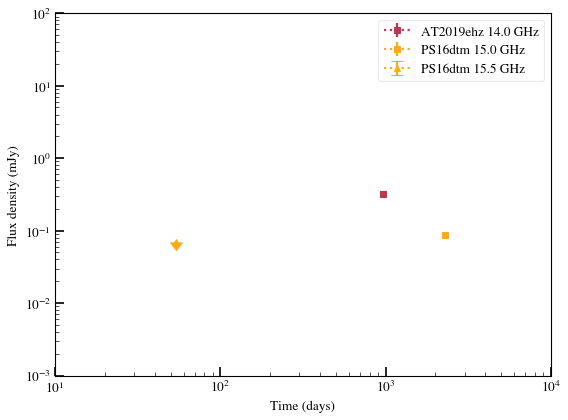

In [41]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)

        # try:
        if np.abs(float(freq)-15) > 1:
            continue
        # except:
        #     print(freq)
        #     continue
        # unique = True
        marker_num+=1
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                # print(freq,  dict_events[event]['flux density (mJy)'][i])
                # print(i,unique)
            #     print(dict_events[event]['freq (GHz)'][i],dict_events[event]['flux density (mJy)'][i],dict_events[event]['error (mJy)'][i])
                # if unique:
                #     label = f'{event} {freq} GHz'
                # else:
                #     label = None
        # print(freq_array)
        ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['flux density (mJy)'][freq_array], 
                    yerr=dict_events[event]['error (mJy)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e-3,1e2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Flux density (mJy)')
plt.legend()

Lnu (erg/s/Hz)

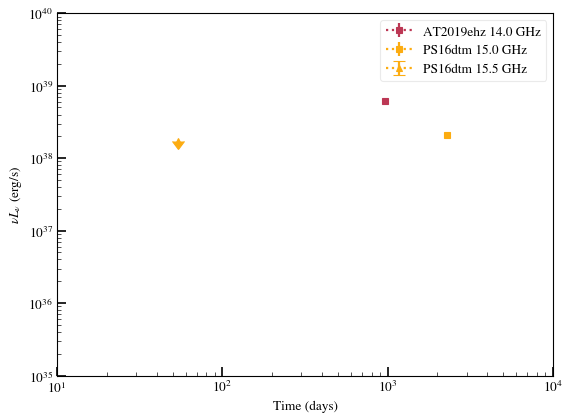

In [42]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)
# 
        # try:
        if np.abs(float(freq)-15) > 1:
            continue
        # except:
        #     print(freq)
        #     continue
        # unique = True
        marker_num+=1
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
                    
        ax.errorbar(dict_events[event]['times (d)'][freq_array], float(freq)*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=float(freq)*1e9*dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e35,1e40)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\nu L_{\nu}$ (erg/s)')
plt.legend()

ASASSN-14ae [6.67783842e+37 1.64576405e+38]
ASASSN-14ae [7.89851856e+37 1.90091013e+38]
AT2018dyb [1.81493955e+37]
AT2018hco [2.83030229e+38 1.95132643e+38]
AT2018hco [7.97133448e+38]
AT2018zr [9.88853451e+37]
AT2018zr [1.16739644e+38]
AT2019ehz [7.38293199e+37 3.19927053e+37 4.93425955e+38 2.26409914e+38]
AT2019ehz [5.08328540e+38 1.66936296e+38]
AT2019eve [5.73840011e+38 4.47148061e+38 4.05414242e+38]
AT2019eve [4.04420579e+38 1.09302859e+40]
AT2019teq [1.2129867e+38]
AT2019teq [9.88359531e+37]
PS16dtm [3.73404734e+38]
PS16dtm [1.44240544e+38]
PS16dtm [4.06466611e+38]
iPTF16fnl [1.30308323e+36]
iPTF16fnl [1.52629656e+36]


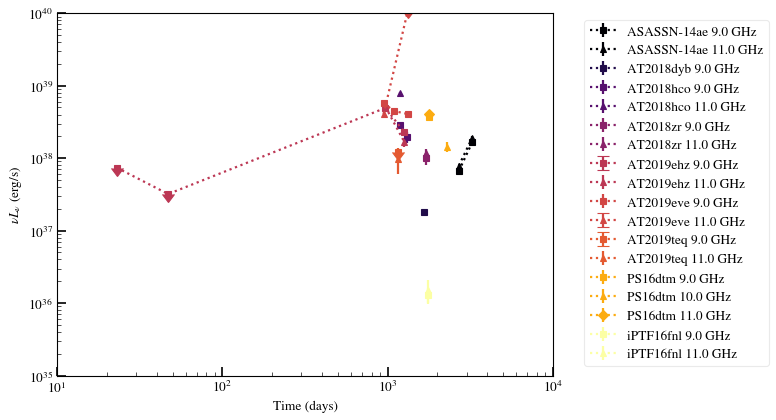

In [43]:
fig,ax = plt.subplots(figsize=(8, 6))
colors_array = plt.cm.inferno(np.linspace(0, 1, len(dict_events.keys())))
for event,color in zip(dict_events.keys(), colors_array):
    # if event != 'ASASSN-14ae':
    #     continue
    
    # print(len(np.unique(dict_events[event]['freq (GHz)'])))
    marker_array = ['o','s','^','D','v','<','>','p','h','8']
    marker_num =0
    for freq in np.unique(dict_events[event]['freq (GHz)']):
        # print(color,freq)

        # try:
        if np.abs(float(freq)-10) > 1:
            continue
        # except:
        #     print(freq)
        #     continue
        # unique = True
        marker_num+=1
        freq_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event]['freq (GHz)'])):
            if dict_events[event]['freq (GHz)'][i] == freq:
                # print(i)
                freq_array = np.append(freq_array,i)
                if dict_events[event]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        print(event, float(freq)*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array])
        ax.errorbar(dict_events[event]['times (d)'][freq_array], float(freq)*1e9*dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                    yerr=float(freq)*1e9*dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,
                    ms=6, color=color, label=f'{event} {freq} GHz',linestyle=':')
                # unique=False
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(10,1e4)
ax.set_ylim(1e35,1e40)
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\nu L_{\nu}$ (erg/s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')